### Imports

In [1]:
import numpy as np
import timm
import torch
import torch.nn as nn
from sklearn.utils.class_weight import compute_class_weight
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

from allium_cepa_classifier.config.training_config import TrainingConfig

### Project config

In [ ]:
config = TrainingConfig()
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = config.batch_size  # 32
IMAGE_SIZE = config.image_size  # (200, 200)
EPOCHS = 30
LR = 1e-5
MODEL_NAME = "efficientNetB1"

# Reproducibility
SEED = config.seed
torch.manual_seed(SEED)
np.random.seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print(f"Device: {DEVICE}")

Device: cuda


### Transforms

In [3]:
# ImageNet normalization stats (timm efficientnet_b1 expects these)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose(
    [
        transforms.Resize(IMAGE_SIZE),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ]
)

eval_transforms = transforms.Compose(
    [
        transforms.Resize(IMAGE_SIZE),
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ]
)

### Dataset preparation

In [4]:
# torchvision ImageFolder expects: root/{class_name}/image.png
# Existing crops dir layout:
#   datasets/crops/binary_classifier/{split}/{mitosis|no_mitosis}/
train_dir = config.binary_classifier_crops_dir / "train"
validation_dir = config.binary_classifier_crops_dir / "validation"
test_dir = config.binary_classifier_crops_dir / "test"

train_dataset = datasets.ImageFolder(train_dir, transform=train_transforms)
val_dataset = datasets.ImageFolder(validation_dir, transform=eval_transforms)
test_dataset = datasets.ImageFolder(test_dir, transform=eval_transforms)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True
)

# Class mapping: ImageFolder assigns indices alphabetically.
# 'mitosis' < 'no_mitosis' -> class_to_idx = {'mitosis': 0, 'no_mitosis': 1}
# This matches the existing convention: argmax == 0 -> mitosis.
print("Class mapping:", train_dataset.class_to_idx)
assert train_dataset.class_to_idx == {"mitosis": 0, "no_mitosis": 1}, (
    "Unexpected class order — check the crops directory structure."
)

Class mapping: {'mitosis': 0, 'no_mitosis': 1}


### Class balancing

In [5]:
train_labels = [label for _, label in train_dataset.samples]
class_weights = compute_class_weight("balanced", classes=np.array([0, 1]), y=np.array(train_labels))
print(class_weights)
# Same manual adjustment as original notebook:
class_weights[0] *= 2  # upweight mitosis
class_weights[1] *= 0.5  # downweight no_mitosis

weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)
print(f"Class weights: mitosis={class_weights[0]:.3f}, no_mitosis={class_weights[1]:.3f}")

[     5.2177     0.55299]
Class weights: mitosis=10.435, no_mitosis=0.276


### Model definition

In [6]:
def build_model(num_classes: int = 2) -> nn.Module:
    model = timm.create_model("efficientnet_b2", pretrained=True)

    # Freeze early blocks (equivalent to freezing before block6a in Keras):
    # timm blocks[0..4] ~= Keras block1a..block5x
    # timm blocks[5..6] ~= Keras block6a..block7a  <- kept trainable
    for param in model.conv_stem.parameters():
        param.requires_grad = False
    for param in model.bn1.parameters():
        param.requires_grad = False
    for i in range(5):  # freeze blocks 0-4
        for param in model.blocks[i].parameters():
            param.requires_grad = False

    # Replace classifier head
    # Note: timm applies GlobalAveragePooling2D internally before the classifier head.
    in_features = model.classifier.in_features
    model.classifier = nn.Sequential(
        nn.Linear(in_features, 512),
        nn.LeakyReLU(negative_slope=0.2),
        nn.Dropout(0.3),
        nn.Linear(512, 256),
        nn.LeakyReLU(negative_slope=0.2),
        nn.Dropout(0.2),
        nn.Linear(256, 128),
        nn.LeakyReLU(negative_slope=0.2),
        nn.Linear(128, num_classes),  # raw logits (no softmax — CrossEntropyLoss expects logits)
    )
    return model


model = build_model().to(DEVICE)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Trainable params: {trainable:,} / {total:,}")

model.safetensors:   0%|          | 0.00/36.8M [00:00<?, ?B/s]

Trainable params: 7,169,020 / 8,586,884


### Optimizer, scheduler, loss

In [7]:
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.2, patience=5, min_lr=1e-6, threshold=0.01
)
criterion = nn.CrossEntropyLoss(weight=weights_tensor)

### Training loop

In [8]:
import time

best_val_loss = float("inf")
best_state = None
patience_counter = 0
EARLY_STOPPING_PATIENCE = 10
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

for epoch in range(1, EPOCHS + 1):
    epoch_start = time.time()

    # --- Train ---
    model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * images.size(0)
        train_correct += (logits.argmax(dim=1) == labels).sum().item()
        train_total += images.size(0)

    # --- Validate ---
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            logits = model(images)
            loss = criterion(logits, labels)
            val_loss += loss.item() * images.size(0)
            val_correct += (logits.argmax(dim=1) == labels).sum().item()
            val_total += images.size(0)

    epoch_time = time.time() - epoch_start
    avg_train_loss = train_loss / train_total
    avg_val_loss = val_loss / val_total
    train_acc = train_correct / train_total
    val_acc = val_correct / val_total

    history["train_loss"].append(avg_train_loss)
    history["val_loss"].append(avg_val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    scheduler.step(avg_val_loss)

    # Early stopping (restore_best_weights=True equivalent)
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1

    current_lr = optimizer.param_groups[0]["lr"]
    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"time={epoch_time:.1f}s | "
        f"train_loss={avg_train_loss:.4f} acc={train_acc:.4f} | "
        f"val_loss={avg_val_loss:.4f} acc={val_acc:.4f} | "
        f"lr={current_lr:.2e} | patience={patience_counter}"
    )

    if patience_counter >= EARLY_STOPPING_PATIENCE:
        print(f"Early stopping at epoch {epoch}.")
        break

# Restore best weights
model.load_state_dict(best_state)
print(f"Restored best weights (val_loss={best_val_loss:.4f})")

Epoch 01/20 | time=50.3strain_loss=0.4258 acc=0.5437 | val_loss=0.7216 acc=0.6953 | lr=1.00e-05 | patience=0
Epoch 02/20 | time=47.0strain_loss=0.2989 acc=0.7547 | val_loss=0.4923 acc=0.7711 | lr=1.00e-05 | patience=0
Epoch 03/20 | time=47.1strain_loss=0.2406 acc=0.7944 | val_loss=0.4362 acc=0.7969 | lr=1.00e-05 | patience=0
Epoch 04/20 | time=47.1strain_loss=0.2219 acc=0.7991 | val_loss=0.3906 acc=0.8086 | lr=1.00e-05 | patience=0
Epoch 05/20 | time=47.1strain_loss=0.1996 acc=0.8192 | val_loss=0.3254 acc=0.8453 | lr=1.00e-05 | patience=0
Epoch 06/20 | time=48.4strain_loss=0.1875 acc=0.8402 | val_loss=0.3673 acc=0.8332 | lr=1.00e-05 | patience=1
Epoch 07/20 | time=49.2strain_loss=0.1787 acc=0.8480 | val_loss=0.2893 acc=0.8712 | lr=1.00e-05 | patience=0
Epoch 08/20 | time=49.3strain_loss=0.1697 acc=0.8658 | val_loss=0.2818 acc=0.8767 | lr=1.00e-05 | patience=0
Epoch 09/20 | time=50.4strain_loss=0.1535 acc=0.8650 | val_loss=0.2925 acc=0.8688 | lr=1.00e-05 | patience=1
Epoch 10/20 | time=

### Training curves

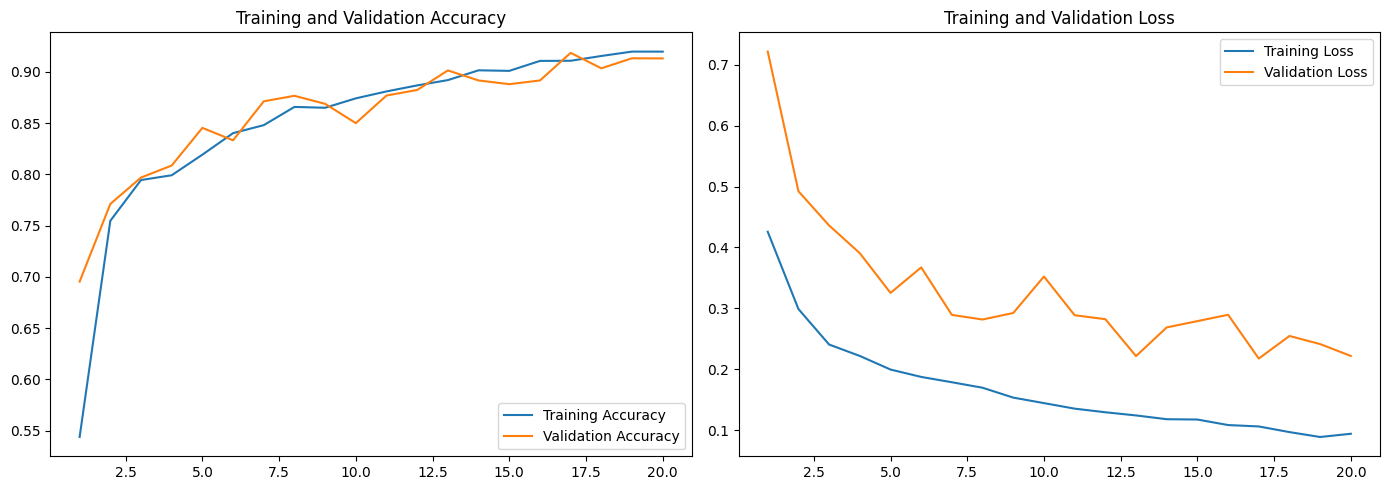

In [9]:
import matplotlib.pyplot as plt

epochs_range = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, history["train_acc"], label="Training Accuracy")
plt.plot(epochs_range, history["val_acc"], label="Validation Accuracy")
plt.legend(loc="lower right")
plt.title("Training and Validation Accuracy")

plt.subplot(1, 2, 2)
plt.plot(epochs_range, history["train_loss"], label="Training Loss")
plt.plot(epochs_range, history["val_loss"], label="Validation Loss")
plt.legend(loc="upper right")
plt.title("Training and Validation Loss")

plt.tight_layout()
plt.show()

### Testing

Test accuracy: 0.9264

              precision    recall  f1-score   support

     mitosis       0.53      0.89      0.67       461
  no_mitosis       0.99      0.93      0.96      5085

    accuracy                           0.93      5546
   macro avg       0.76      0.91      0.81      5546
weighted avg       0.95      0.93      0.93      5546



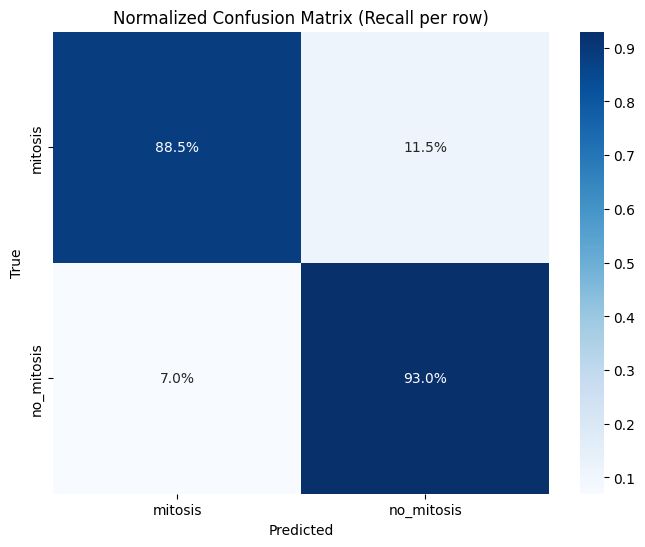

In [10]:
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

model.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)
        logits = model(images)
        y_pred.extend(logits.argmax(dim=1).cpu().numpy())
        y_true.extend(labels.numpy())

class_names = list(train_dataset.class_to_idx.keys())
print(
    f"Test accuracy: {sum(p == t for p, t in zip(y_pred, y_true, strict=False)) / len(y_true):.4f}"
)
print()
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred, normalize="true")
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt=".1%", cmap="Blues", xticklabels=class_names, yticklabels=class_names
)
plt.title("Normalized Confusion Matrix (Recall per row)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

### Save model

In [ ]:
save_path = config.model_path / f"classifier_{MODEL_NAME}_{EPOCHS}E.pt"
torch.save(
    {
        "model_state_dict": best_state,
        "timm_model_name": "efficientnet_b2",
        "num_classes": 2,
        "image_size": IMAGE_SIZE,
        "class_to_idx": train_dataset.class_to_idx,
        "imagenet_mean": IMAGENET_MEAN,
        "imagenet_std": IMAGENET_STD,
    },
    save_path,
)
print(f"Saved: {save_path}")

# Quick sanity check on the saved file
ckpt = torch.load(save_path, map_location="cpu")
assert set(ckpt.keys()) == {
    "model_state_dict",
    "timm_model_name",
    "num_classes",
    "image_size",
    "class_to_idx",
    "imagenet_mean",
    "imagenet_std",
}
assert ckpt["class_to_idx"] == {"mitosis": 0, "no_mitosis": 1}
print("Checkpoint verified.")